In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
word_embedding = {
    "Cat":[0.8,0.6],
    "Kitten":[0.75,0.65],
    "Dog":[0.7,0.3],
    "Puppy":[0.65,0.35],
    "Car":[-0.5,0.2],
    "Truck":[-0.45,0.15]
}

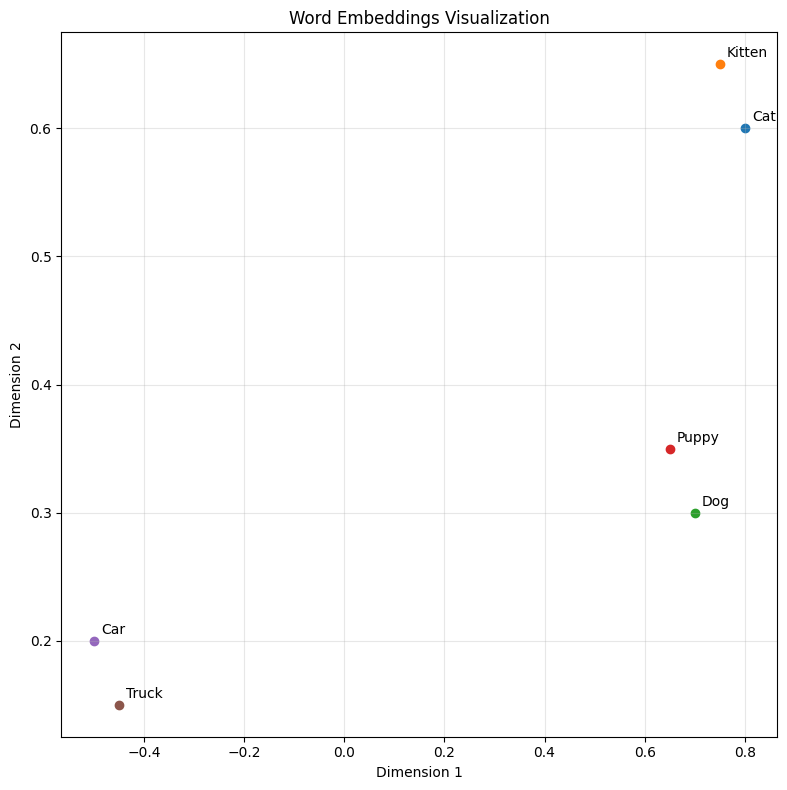

In [4]:
fig,ax = plt.subplots(figsize=(8,8))

for word,embedding in word_embedding.items():
    ax.scatter(embedding[0],embedding[1])
    ax.annotate(word,(embedding[0],embedding[1]),xytext=(5,5),textcoords='offset points')

ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Word Embeddings Visualization')
ax.grid(True,alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
def cosine_similarity(vec1,vec2):

    """
    Calculate the cosine similarity between two vectors.
    - Result closer to 1 indicates high similarity, while closer to -1 indicates dissimilarity.
    - Results closer to 0 indicate orthogonality or no similarity.
    """

    dot_product = np.dot(vec1,vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)

    return dot_product/(norm_vec1*norm_vec2)

In [6]:
cat_vector = [0.8,0.6,0.3]
kitten_vector = [0.75,0.65,0.35]
car_vector = [-0.5,0.2,0.1]

In [7]:
cosine_similarity(cat_vector,kitten_vector)

np.float64(0.9966186334192181)

In [8]:
cosine_similarity(kitten_vector,car_vector)

np.float64(-0.36432317655505975)

In [9]:
cosine_similarity(car_vector,cat_vector)

np.float64(-0.43718588548916804)

In [1]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings  = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
embeddings

c:\Users\10139518\Downloads\RAG\Practise\Types Of Rag\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1519.65it/s]


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [2]:
embeddings.embed_query("Hello This is Kalyan")

[-0.09745779633522034,
 0.03797897696495056,
 -0.06037763133645058,
 0.0008340200292877853,
 -0.05481410771608353,
 -0.0791226252913475,
 0.07912161946296692,
 -0.09972325712442398,
 -0.023452740162611008,
 0.0065669831819832325,
 0.05140669643878937,
 -0.00988548994064331,
 -0.07331395894289017,
 -0.0017634701216593385,
 -0.003751117270439863,
 -0.019602173939347267,
 0.04736068472266197,
 -0.0050597661174833775,
 -0.07997706532478333,
 -0.03935336321592331,
 -0.07487719506025314,
 0.028675204142928123,
 -0.028185658156871796,
 0.006497150287032127,
 -0.0038337567821145058,
 -0.0432029627263546,
 0.016264833509922028,
 0.04270314797759056,
 0.0833820179104805,
 -0.048331983387470245,
 -7.268538320204243e-05,
 0.03523458540439606,
 0.021696574985980988,
 0.00618711207062006,
 0.015219075605273247,
 0.1004842221736908,
 -0.136867955327034,
 0.006088154390454292,
 -0.015248582698404789,
 -0.025578362867236137,
 -0.01868862472474575,
 -0.03950119763612747,
 -0.01754116080701351,
 -0.06356

In [3]:
sentences = [
    "The cat sat on the mat",
    "The dog played in the yard",
    "I love programming in Python",
    "Python is my favorite programming language"
]

embedding_sentence=embeddings.embed_documents(sentences)

print(embedding_sentence[0])
print(embedding_sentence[1])
print(embedding_sentence[2])
print(embedding_sentence[3])

[0.1304018199443817, -0.011870108544826508, -0.02811702899634838, 0.05123864486813545, -0.05597446486353874, 0.030191557481884956, 0.03016129694879055, 0.024698374792933464, -0.018370570614933968, 0.05876679718494415, -0.02495316043496132, 0.06015423312783241, 0.0398317389190197, 0.033230509608983994, -0.061311397701501846, -0.04937313124537468, -0.05486350506544113, -0.04007608816027641, 0.05642912536859512, 0.03915657103061676, -0.03473709896206856, -0.01324769388884306, 0.0319661982357502, -0.06349923461675644, -0.060178596526384354, 0.07823446393013, -0.028303883969783783, -0.04744284600019455, 0.04035928472876549, -0.006630894262343645, -0.06674095243215561, -0.004191364161670208, -0.025311673060059547, 0.053341660648584366, 0.017428100109100342, -0.0979236289858818, 0.006061299238353968, -0.06524164974689484, 0.045572590082883835, 0.02364179491996765, 0.0765848383307457, -0.010264378041028976, -0.004076802637428045, -0.06232285499572754, 0.03370529040694237, 0.018661106005311012,

In [4]:
from langchain_huggingface import HuggingFaceEmbeddings
import time

# Popular models comparison
models = {
    "all-MiniLM-L6-v2": {
        "size": 384,
        "description": "Fast and efficient, good quality",
        "use_case": "General purpose, real-time applications"
    },
    "all-mpnet-base-v2": {
        "size": 768,
        "description": "Best quality, slower than MiniLM",
        "use_case": "When quality matters more than speed"
    },
    "all-MiniLM-L12-v2": {
        "size": 384,
        "description": "Slightly better than L6, bit slower",
        "use_case": "Good balance of speed and quality"
    },
    "multi-qa-MiniLM-L6-cos-v1": {
        "size": 384,
        "description": "Optimized for question-answering",
        "use_case": "Q&A systems, semantic search"
    },
    "paraphrase-multilingual-MiniLM-L12-v2": {
        "size": 384,
        "description": "Supports 50+ languages",
        "use_case": "Multilingual applications"
    }
}

print("📊 Popular Open Source Embedding Models:\n")
for model_name, info in models.items():
    print(f"Model: sentence-transformers/{model_name}")
    print(f"  📏 Embedding size: {info['size']} dimensions")
    print(f"  📝 Description: {info['description']}")
    print(f"  🎯 Use case: {info['use_case']}\n")


📊 Popular Open Source Embedding Models:

Model: sentence-transformers/all-MiniLM-L6-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Fast and efficient, good quality
  🎯 Use case: General purpose, real-time applications

Model: sentence-transformers/all-mpnet-base-v2
  📏 Embedding size: 768 dimensions
  📝 Description: Best quality, slower than MiniLM
  🎯 Use case: When quality matters more than speed

Model: sentence-transformers/all-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Slightly better than L6, bit slower
  🎯 Use case: Good balance of speed and quality

Model: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
  📏 Embedding size: 384 dimensions
  📝 Description: Optimized for question-answering
  🎯 Use case: Q&A systems, semantic search

Model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Supports 50+ languages
  🎯 Use case: Multilingual applications

